# 2. Trenowanie klasyfikatorów (Random Forest + MLP)

Trenujemy dwa modele przewidujące klasę elementu (Beam/Slab/Stair/Wall)
na podstawie cech geometrycznych z `data/ifc_features.csv`, respektując
istniejący podział `train`/`test`.

In [1]:
%matplotlib inline
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
DATA_CSV = ROOT / "data" / "ifc_features.csv"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

NON_FEATURE_COLS = ["file", "split", "label", "stored_ifc_class", "type_mismatch", "guid", "name"]

In [2]:
df = pd.read_csv(DATA_CSV)
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
train = df[df["split"] == "train"]
test = df[df["split"] == "test"]
labels = sorted(df["label"].unique())

X_train, y_train = train[feature_cols].values, train["label"].values
X_test, y_test = test[feature_cols].values, test["label"].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train rows: {len(train)}, test rows: {len(test)}, features: {len(feature_cols)}")
train["label"].value_counts()

train rows: 965, test rows: 413, features: 39


label
Wall     376
Slab     355
Beam     198
Stair     36
Name: count, dtype: int64

In [3]:
def evaluate(name, y_true, y_pred, labels):
    report = classification_report(y_true, y_pred, labels=labels, digits=3)
    print(f"=== {name} ===")
    print(report)
    (REPORTS_DIR / f"classification_report_{name}.txt").write_text(report, encoding="utf-8")

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion matrix - {name}")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

## Random Forest

=== random_forest ===
              precision    recall  f1-score   support

        Beam      0.926     0.893     0.909        84
        Slab      0.943     0.974     0.958       152
       Stair      1.000     1.000     1.000        16
        Wall      0.987     0.975     0.981       161

    accuracy                          0.959       413
   macro avg      0.964     0.960     0.962       413
weighted avg      0.959     0.959     0.959       413



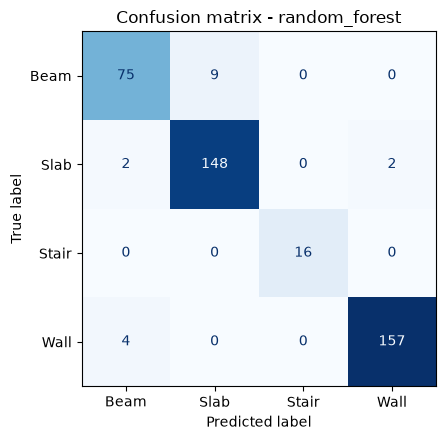

In [4]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
evaluate("random_forest", y_test, rf.predict(X_test), labels)

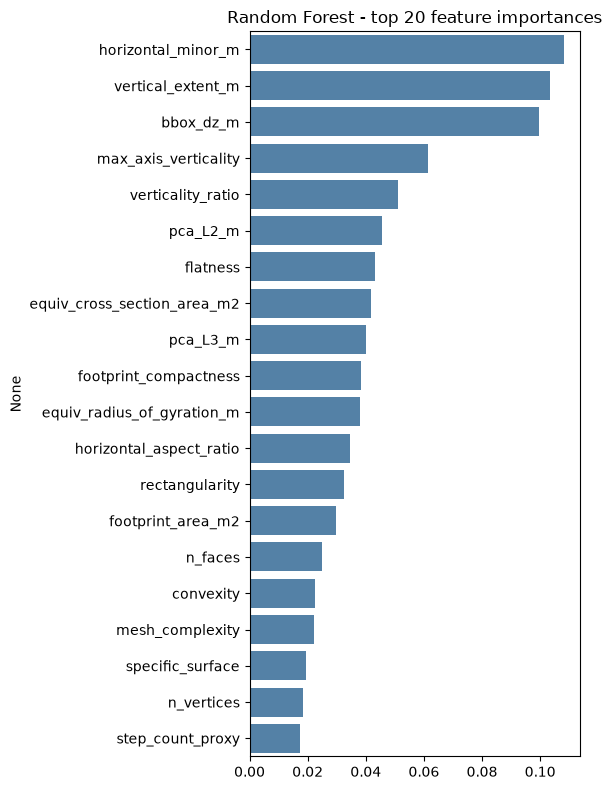

horizontal_minor_m             0.108290
vertical_extent_m              0.103501
bbox_dz_m                      0.099643
max_axis_verticality           0.061400
verticality_ratio              0.051101
pca_L2_m                       0.045726
flatness                       0.043107
equiv_cross_section_area_m2    0.041829
pca_L3_m                       0.039907
footprint_compactness          0.038186
dtype: float64

In [5]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=importances.values[:20], y=importances.index[:20], ax=ax, color="steelblue")
ax.set_title("Random Forest - top 20 feature importances")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "feature_importances_rf.png", dpi=150)
plt.show()

importances.to_csv(REPORTS_DIR / "feature_importances_rf.csv")
importances.head(10)

## MLP (Multi-Layer Perceptron)

=== mlp ===
              precision    recall  f1-score   support

        Beam      0.905     0.798     0.848        84
        Slab      0.913     0.967     0.939       152
       Stair      1.000     1.000     1.000        16
        Wall      0.963     0.969     0.966       161

    accuracy                          0.935       413
   macro avg      0.945     0.933     0.938       413
weighted avg      0.934     0.935     0.933       413



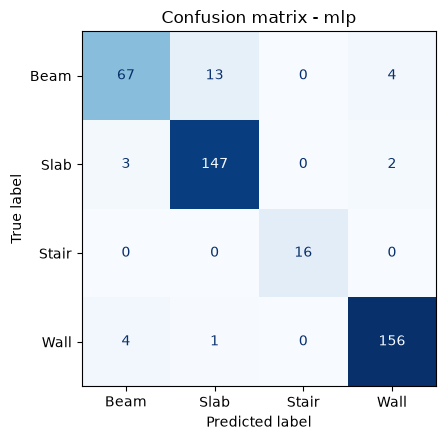

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-3,
    max_iter=3000,
    early_stopping=True,
    random_state=42,
)
mlp.fit(X_train_s, y_train)
evaluate("mlp", y_test, mlp.predict(X_test_s), labels)

## Diagnostyka przeuczenia (overfitting)

Zanim zapiszemy modele, sprawdzamy czy nie sa przeuczone - czyli czy nie
"wyuczyly sie na pamiec" zbioru treningowego kosztem generalizacji. Patrzymy
na cztery rzeczy: (1) roznice train vs test accuracy, (2) krzywe uczenia
(train/walidacja w funkcji liczby probek), (3) krzywa walidacyjna Random
Forest w funkcji liczby drzew, (4) krzywa straty MLP w kolejnych epokach.

               train_accuracy  test_accuracy       gap
model                                                 
Random Forest        0.998964       0.958838  0.040126
MLP                  0.973057       0.934625  0.038432


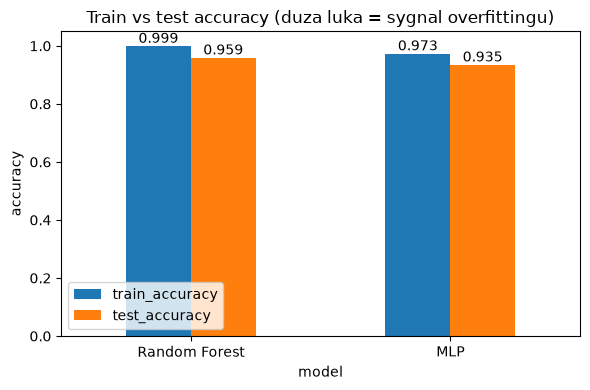

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score

acc_rows = []
for name, model, Xtr, Xte in [
    ("Random Forest", rf, X_train, X_test),
    ("MLP", mlp, X_train_s, X_test_s),
]:
    acc_rows.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(Xtr)),
        "test_accuracy": accuracy_score(y_test, model.predict(Xte)),
    })
acc_df = pd.DataFrame(acc_rows).set_index("model")
acc_df["gap"] = acc_df["train_accuracy"] - acc_df["test_accuracy"]
print(acc_df)

ax = acc_df[["train_accuracy", "test_accuracy"]].plot(kind="bar", figsize=(6, 4), rot=0, ylim=(0, 1.05))
ax.set_ylabel("accuracy")
ax.set_title("Train vs test accuracy (duza luka = sygnal overfittingu)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "train_vs_test_accuracy.png", dpi=150)
plt.show()

### Krzywe uczenia (learning curves)

Trenujemy model wielokrotnie na coraz wiekszej czesci danych treningowych
(z walidacja krzyzowa 5-fold na zbiorze train), i patrzymy jak zmienia sie
accuracy na probce treningowej vs na foldzie walidacyjnym. Duza i utrzymujaca
sie luka miedzy krzywymi to typowy obraz overfittingu; zbiegajace sie krzywe
(zwlaszcza gdy walidacja przestaje rosnac przy wiekszej liczbie danych)
sugeruja, ze model dobrze generalizuje.

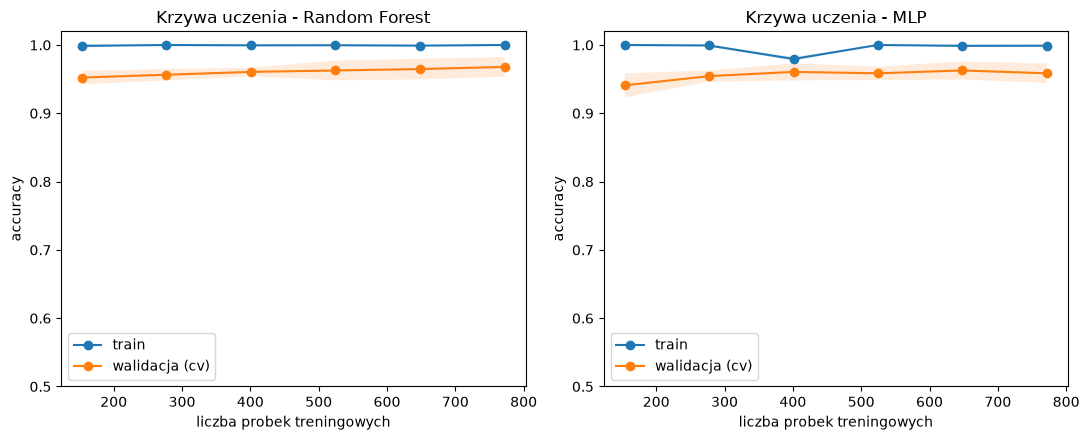

In [8]:
from sklearn.model_selection import StratifiedKFold, learning_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.2, 1.0, 6)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model, X, y, name in [
    (axes[0], RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1),
     X_train, y_train, "Random Forest"),
    (axes[1], MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=3000, random_state=42),
     X_train_s, y_train, "MLP"),
]:
    sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, train_sizes=train_sizes, scoring="accuracy", n_jobs=-1,
        shuffle=True, random_state=42,
    )
    ax.plot(sizes, train_scores.mean(axis=1), "o-", label="train")
    ax.plot(sizes, val_scores.mean(axis=1), "o-", label="walidacja (cv)")
    ax.fill_between(sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15)
    ax.fill_between(sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15)
    ax.set_title(f"Krzywa uczenia - {name}")
    ax.set_xlabel("liczba probek treningowych")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.5, 1.02)
    ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "learning_curves.png", dpi=150)
plt.show()

### Krzywa walidacyjna Random Forest (liczba drzew)

Sprawdzamy jak accuracy train/walidacja zmienia sie wraz z `n_estimators`.
Jesli krzywa walidacyjna plateau'uje (przestaje rosnac), a nie spada wraz ze
wzrostem liczby drzew, to Random Forest nie przeucza sie od samej liczby
drzew - to zgodne z teoria (wiecej drzew redukuje wariancje, nie zwieksza
overfittingu, w przeciwienstwie np. do glebokosci pojedynczego drzewa).

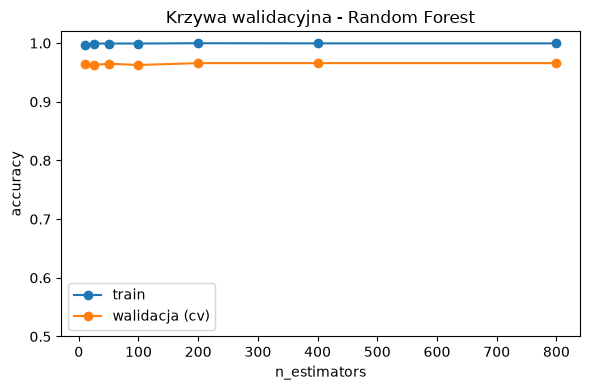

In [9]:
from sklearn.model_selection import validation_curve

param_range = [10, 25, 50, 100, 200, 400, 800]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    X_train, y_train, param_name="n_estimators", param_range=param_range,
    cv=cv, scoring="accuracy", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(param_range, train_scores.mean(axis=1), "o-", label="train")
ax.plot(param_range, val_scores.mean(axis=1), "o-", label="walidacja (cv)")
ax.set_xlabel("n_estimators")
ax.set_ylabel("accuracy")
ax.set_title("Krzywa walidacyjna - Random Forest")
ax.set_ylim(0.5, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "validation_curve_rf.png", dpi=150)
plt.show()

### Krzywa straty MLP (loss curve)

`early_stopping=True` w MLP odklada 10% danych treningowych jako wewnetrzny
zbior walidacyjny i pilnuje `validation_scores_` w kolejnych epokach. Jesli
strata treningowa dalej spada, a accuracy walidacyjne przestaje rosnac (albo
zaczyna spadac), to znak przeuczania - tutaj `early_stopping` powinien
zatrzymac trening zanim to nastapi.

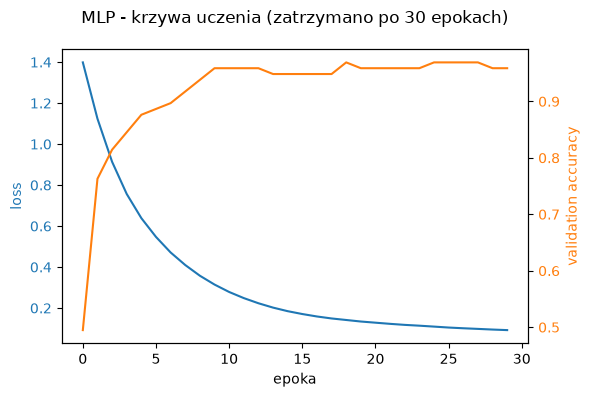

In [10]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(mlp.loss_curve_, color="tab:blue", label="strata treningowa")
ax1.set_xlabel("epoka")
ax1.set_ylabel("loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    ax2 = ax1.twinx()
    ax2.plot(mlp.validation_scores_, color="tab:orange", label="accuracy walidacyjne")
    ax2.set_ylabel("validation accuracy", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle(f"MLP - krzywa uczenia (zatrzymano po {len(mlp.loss_curve_)} epokach)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "mlp_loss_curve.png", dpi=150)
plt.show()

### ROC / AUC (wieloklasowe, one-vs-rest)

Accuracy nie mowi nic o tym, jak pewne/dobrze skalibrowane sa predykcje
prawdopodobienstwa. ROC-AUC (per klasa, one-vs-rest) to dodatkowa,
niezalezna miara jakosci separacji klas. Podobnie jak z accuracy, patrzymy
najpierw na luke train vs test AUC (duza luka = overfitting), a potem na
pelne krzywe ROC per klasa na zbiorze testowym.

               train_auc  test_auc       gap
model                                       
Random Forest   1.000000  0.997768  0.002232
MLP             0.993462  0.985896  0.007566


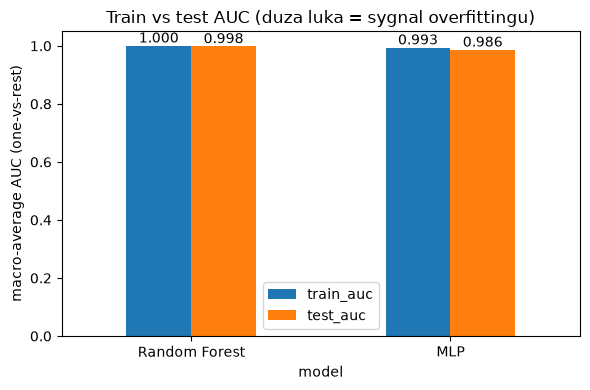

In [11]:
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_train_bin = label_binarize(y_train, classes=labels)
y_test_bin = label_binarize(y_test, classes=labels)


def macro_auc(model, X, y_bin):
    proba = model.predict_proba(X)
    return roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")


auc_rows = []
for name, model, Xtr, Xte in [
    ("Random Forest", rf, X_train, X_test),
    ("MLP", mlp, X_train_s, X_test_s),
]:
    auc_rows.append({
        "model": name,
        "train_auc": macro_auc(model, Xtr, y_train_bin),
        "test_auc": macro_auc(model, Xte, y_test_bin),
    })
auc_df = pd.DataFrame(auc_rows).set_index("model")
auc_df["gap"] = auc_df["train_auc"] - auc_df["test_auc"]
print(auc_df)

ax = auc_df[["train_auc", "test_auc"]].plot(kind="bar", figsize=(6, 4), rot=0, ylim=(0, 1.05))
ax.set_ylabel("macro-average AUC (one-vs-rest)")
ax.set_title("Train vs test AUC (duza luka = sygnal overfittingu)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "train_vs_test_auc.png", dpi=150)
plt.show()

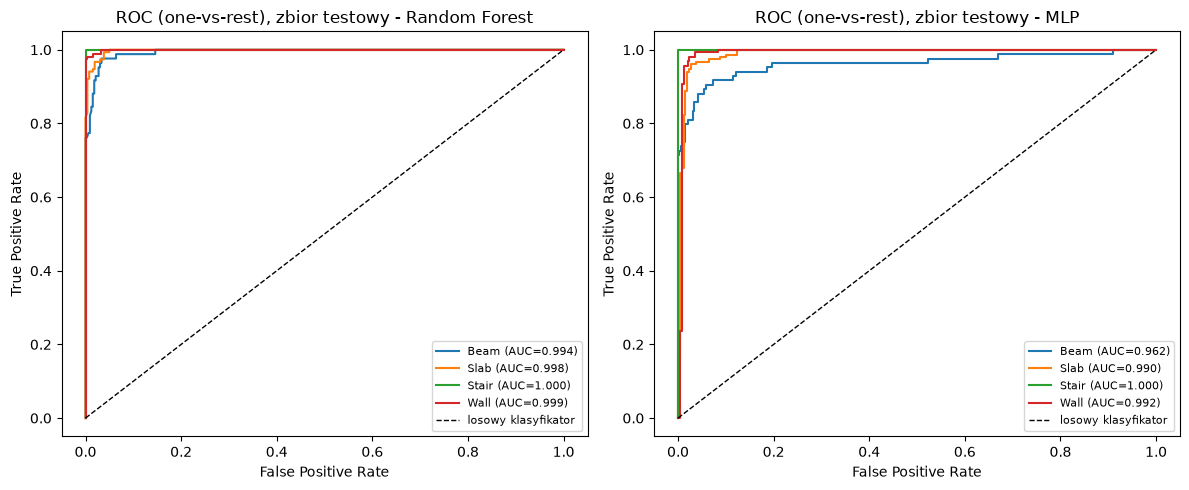

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, Xte, name in [
    (axes[0], rf, X_test, "Random Forest"),
    (axes[1], mlp, X_test_s, "MLP"),
]:
    proba = model.predict_proba(Xte)
    for i, cls in enumerate(model.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={class_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="losowy klasyfikator")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC (one-vs-rest), zbior testowy - {name}")
    ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "roc_curves.png", dpi=150)
plt.show()

## Zapis modeli

In [13]:
joblib.dump(rf, MODELS_DIR / "random_forest.joblib")
joblib.dump(mlp, MODELS_DIR / "mlp.joblib")
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
joblib.dump(feature_cols, MODELS_DIR / "feature_cols.joblib")

print(f"saved models -> {MODELS_DIR}")

saved models -> C:\Users\agata\OneDrive\Desktop\Test\ifc_test\models
